In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore.csv


In [3]:
df = pd.read_csv("SampleSuperstore.csv")

In [4]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 13)

In [6]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [8]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# 📊 E-Commerce Sales Analysis
## Analysis 1: Sales by Region

In [9]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


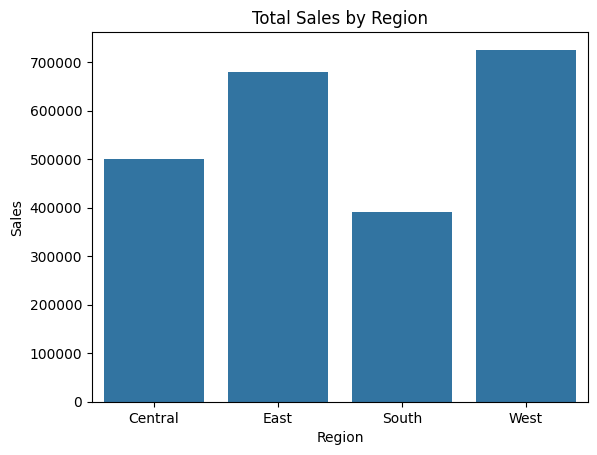

In [10]:
region_sales = df.groupby("Region")["Sales"].sum().reset_index()

sns.barplot(x="Region", y="Sales", data=region_sales)
plt.title("Total Sales by Region")
plt.show()

### Insight

The West region generates the highest total sales, followed by the East region.  
The South region has the lowest sales performance.

This suggests that the company should focus on improving sales strategies in the South region while maintaining strong performance in the West.

## Analysis 2: Sales by Category

In [11]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


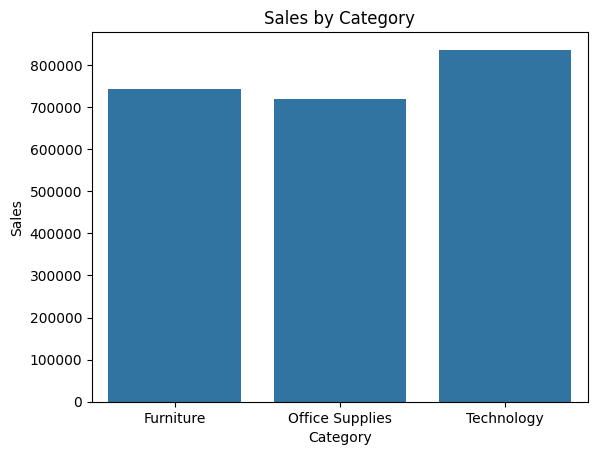

In [12]:
category_sales = df.groupby("Category")["Sales"].sum().reset_index()

sns.barplot(x="Category", y="Sales", data=category_sales)
plt.title("Sales by Category")
plt.show()

### Insight

The Technology category generates the highest sales, followed by Furniture.  
Office Supplies contributes the least to total sales.

This indicates that the company should continue focusing on Technology products while improving the performance of Office Supplies.


## Analysis 3: Profit by Category

In [13]:
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
profit_by_category

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


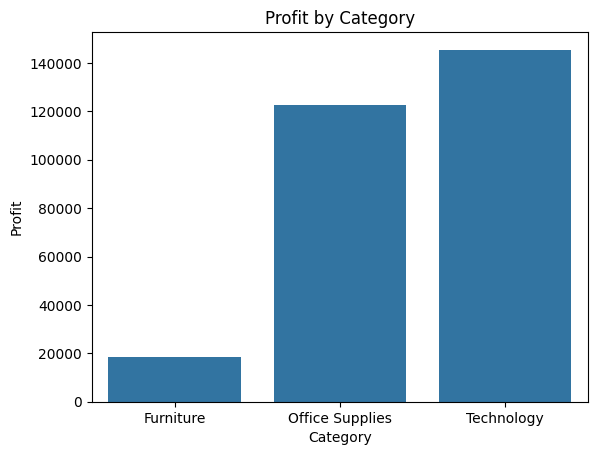

In [14]:
profit_by_category = df.groupby("Category")["Profit"].sum().reset_index()

sns.barplot(x="Category", y="Profit", data=profit_by_category)
plt.title("Profit by Category")
plt.show()

### Insight

The Technology category generates the highest profit, followed by Office Supplies.  
Furniture has comparatively lower profit despite having good sales.

This indicates that some categories may have high sales but lower profitability, possibly due to higher costs or discounts.

## Analysis 4: Sales by Sub-Category

In [15]:
subcat_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
subcat_sales

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


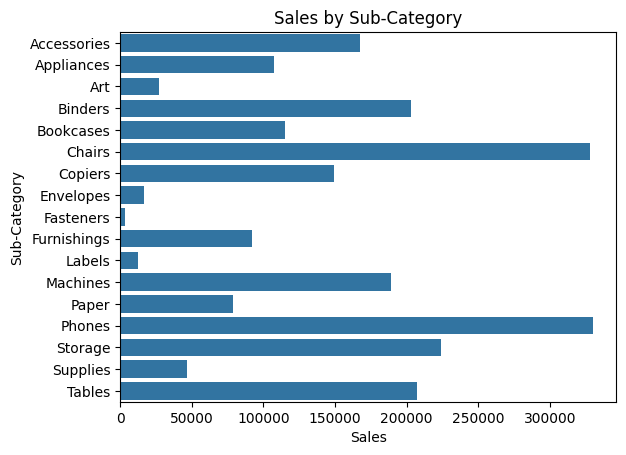

In [16]:
subcat_sales = df.groupby("Sub-Category")["Sales"].sum().reset_index()

sns.barplot(x="Sales", y="Sub-Category", data=subcat_sales)
plt.title("Sales by Sub-Category")
plt.show()

### Insight

Sub-categories like Phones and Chairs generate the highest sales,
while items like Fasteners and Labels contribute the least.

This indicates that the business should focus more on high-performing products
to maximize revenue.

## Analysis 5: Profit vs Discount

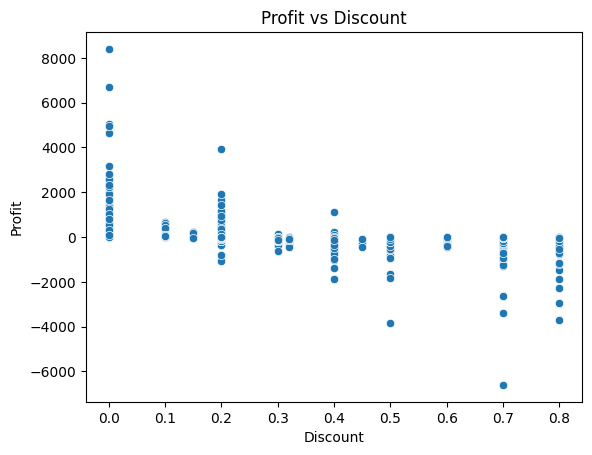

In [17]:
sns.scatterplot(x="Discount", y="Profit", data=df)
plt.title("Profit vs Discount")
plt.show()

In [18]:
df.groupby("Discount")["Profit"].mean()

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


### Insight

As discount increases, profit tends to decrease.  
Higher discount levels often lead to negative profit.

This indicates that offering heavy discounts may reduce profitability
and should be carefully controlled.

## Final Summary

- Analyzed Superstore sales data using Python (Pandas, Seaborn)
- Identified top-performing regions and categories
- Found that Technology drives highest sales and profit
- Discovered seasonal gaps replaced with product-level insights due to missing date data
- Identified top sub-categories like Phones and Chairs
- Analyzed relationship between discount and profit and found that higher discounts reduce profitability

Overall, the analysis provides actionable insights to improve sales strategy, product focus, and discount policies.

# Advanced Analysis 1: Profit by Region

In [19]:
profit_region = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
profit_region

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


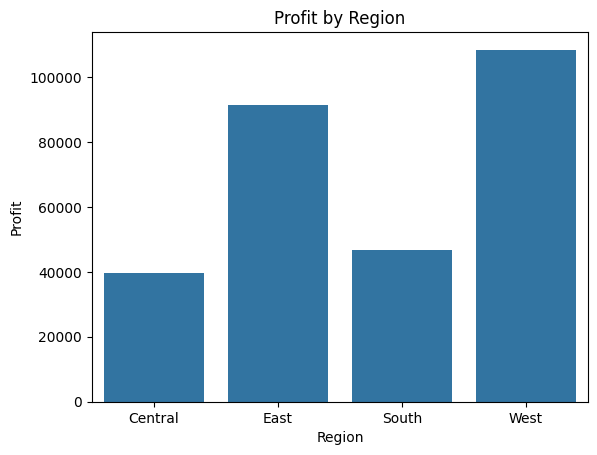

In [20]:
profit_region = df.groupby("Region")["Profit"].sum().reset_index()

sns.barplot(x="Region", y="Profit", data=profit_region)
plt.title("Profit by Region")
plt.show()

### Insight

The West region generates the highest profit, while the Central region has comparatively lower profitability.

This indicates that although some regions may generate good sales, their operational costs or discount strategies may reduce overall profit.

# Advanced Analysis 2: Loss-Making Sub-Categories

In [21]:
loss_products = df.groupby("Sub-Category")["Profit"].sum().sort_values()

loss_products

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


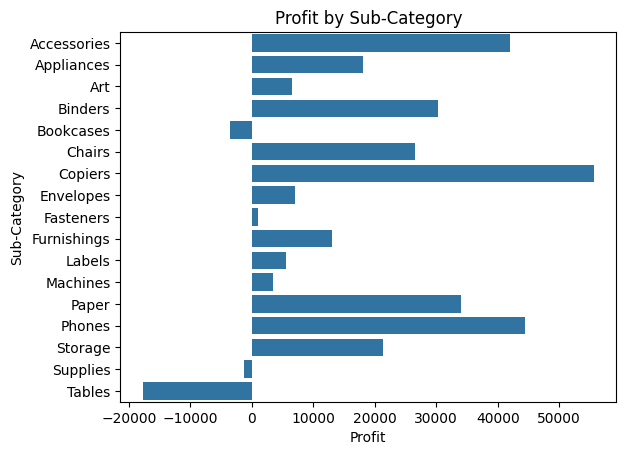

In [22]:
loss_products = df.groupby("Sub-Category")["Profit"].sum().reset_index()

sns.barplot(x="Profit", y="Sub-Category", data=loss_products)
plt.title("Profit by Sub-Category")
plt.show()

### Insight

Sub-categories like Tables and Bookcases generate lower or negative profit despite having considerable sales.

This suggests that pricing, discounting, or operational costs for these products should be reviewed.

# Advanced Analysis 3: Correlation Analysis

In [23]:
df[["Sales", "Profit", "Discount", "Quantity"]].corr()

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.479064,-0.028190,0.200795
Profit,0.479064,1.000000,-0.219487,0.066253
Discount,-0.028190,-0.219487,1.000000,0.008623
Quantity,0.200795,0.066253,0.008623,1.000000


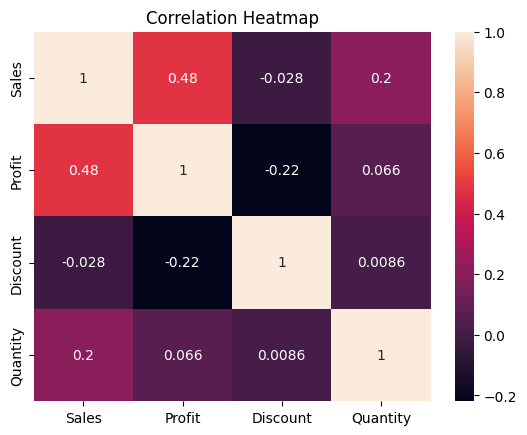

In [24]:
sns.heatmap(df[["Sales", "Profit", "Discount", "Quantity"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Insight

Discount shows a weak negative correlation with profit (-0.22), indicating that higher discounts tend to reduce profitability.

Sales and quantity show a weak positive relationship (0.20), suggesting that selling more units may contribute to increased sales.

Sales and profit have a moderate positive correlation (0.48), meaning higher sales generally contribute to higher profit.

# Executive Summary

This project analyzed Superstore sales data to identify sales trends, profitability patterns, and business opportunities.

Key findings:

• West region generated the highest sales and profit  
• Technology category performed best in both sales and profitability  
• Some sub-categories generated losses despite strong sales  
• Higher discounts showed a negative impact on profit  
• Sales and profit showed a moderate positive relationship

The analysis helps identify areas where business strategies can be improved.

# Business Recommendations

1. Focus marketing efforts on high-performing categories such as Technology.

2. Review pricing and discount strategies for products with low profitability.

3. Investigate loss-making sub-categories such as Tables and Bookcases.

4. Expand successful strategies from high-performing regions to weaker regions.

5. Carefully monitor discount policies to avoid profit reduction.

In [25]:
df.to_csv("superstore_cleaned.csv", index=False)

In [26]:
from google.colab import files
files.download("superstore_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>